# Following splink's example, for the synthetic dataset

We follow the steps done in 

`https://moj-analytical-services.github.io/splink/demos/examples/duckdb/transactions.html`

while adapting the datasets for the synthetic dataset.

In [1]:
# Required dependencies
import pandas as pd
import numpy as np
import os
import sys
import yaml

from splink import DuckDBAPI, Linker, SettingsCreator, block_on


import matplotlib.pyplot as plt
import pyarrow as pa
import pyarrow.parquet as pq

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8')
%matplotlib inline

# Notebook config helper, handles path config and package imports 
from notebook_helper import setup_notebook_environment
helper = setup_notebook_environment()

from em_pipeline.data_loader import (
    load_pair_dfs_from_paths,
    standardise_dt,
    plot_numerical_distribution
)
from em_pipeline.splink_helper import (
    build_api_with_con,
    get_blocking_rules,
    get_estimating_blocking_rules,
    get_numerical_comparison,
    get_datetime_comparison,
    get_category_comparison
)

In [2]:
NOTEBOOK_NAME = "splink_local_demo"

MEM_LIMIT  = "24GB"
TEMP_DIR   = "/tmp"

# Column names used in the synthetic dataset
LEFT_ID_COL   = "local_source_id"      # appears in both df1 & df2 after loading
RIGHT_ID_COL  = "local_source_id"
UNIQUE_ID_COL = "row_id"                # we eventually attempt to build this for labelling.
GROUND_TRUTH_ID_COL = "latent_event_id"      # used for ground truths
CATEGORICAL_COL   = "categorical"
NUMERIC_COL       = "numerical_noisy"
DATETIME_COL      = "datetime_noisy"

# How strict we want the initial random‑match estimate to be
RECALL_FOR_PRIOR = 0.99   # same as the original notebook

In [3]:
dataset_a_path, dataset_b_path = helper.ensure_dataset_exists('smaller')

print(f"Dataset A path: {dataset_a_path}")
print(f"Dataset B path: {dataset_b_path}")


Dataset A path: /home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/../data/smaller_dataset_a.parquet
Dataset B path: /home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/../data/smaller_dataset_b.parquet


In [4]:
df1, df2 = load_pair_dfs_from_paths(dataset_a_path, dataset_b_path)

print(f"\nDataset A shape: {df1.shape}")
print(f"Dataset B shape: {df2.shape}")

print(f"\nDataset A columns: {list(df1.columns)}")
print(f"Dataset B columns: {list(df2.columns)}")


Dataset A shape: (3337, 8)
Dataset B shape: (3528, 8)

Dataset A columns: ['global_entity_id', 'local_source_id', 'categorical', 'numerical_noisy', 'datetime_noisy', 'first_name_noisy', 'last_name_noisy', 'latent_event_id']
Dataset B columns: ['global_entity_id', 'local_source_id', 'categorical', 'numerical_noisy', 'datetime_noisy', 'first_name_noisy', 'last_name_noisy', 'latent_event_id']


In [5]:
df1["row_id"] = "df1_" + df1.index.astype(str)
df2["row_id"] = "df2_" + df2.index.astype(str)
df1

,global_entity_id,local_source_id,categorical,numerical_noisy,datetime_noisy,first_name_noisy,last_name_noisy,latent_event_id,row_id
0,100068,DF1_100068,CAT_17,196.98,2025-12-31 09:57:22.955605206,Andrew,Jackson,UNI_A_969,df1_0
1,100040,DF1_100040,CAT_9,307.72,2025-12-31 20:06:05.757523370,Mary,Walker,UNI_A_970,df1_1
2,100028,DF1_100028,CAT_3,NaN,2025-12-31 21:11:34.449627993,None,Reynolds,OVER_0,df1_2
3,100001,DF1_100001,CAT_7,148.46,2026-01-01 00:02:30.822674446,Lisa,Johnson,UNI_A_971,df1_3
4,100061,DF1_100061,CAT_18,2351.72,2026-01-01 01:55:27.965896846,Sarah,Alvarez,UNI_A_972,df1_4
...,...,...,...,...,...,...,...,...,...
3332,100024,DF1_100024,None,709.29,2026-06-01 00:31:38.619284462,Cristopher,Garcia,OVER_968,df1_3332
3333,100005,DF1_100005,CAT_14,NaN,2026-06-01 01:23:36.159897339,Sandrateh,Reyes,UNI_A_3335,df1_3333
3334,100042,DF1_100042,CAT_0,2750.99,2026-06-01 02:14:10.892386917,Melissa,King,OVER_967,df1_3334
3335,100031,DF1_100031,None,396.59,2026-06-01 05:19:10.855713953,Carol,Hernandez,UNI_A_3336,df1_3335


### Basic EDA, processing

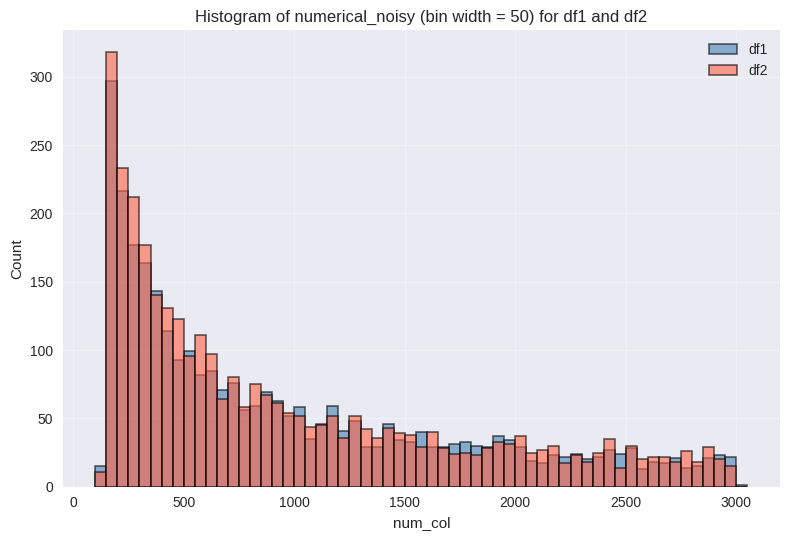

In [6]:
plot_numerical_distribution(df1, df2, "numerical_noisy")

In [7]:
# Basic preprocessing - we currently assume we do not have consistency in time across both DFs. 
# If this is no longer the case, just remove this line and update the datetime comparisons/blocking accordingly.
standardise_dt(df1, df2, DATETIME_COL)

Set datetime_noisy to date for both df1 and df2.


In [8]:
df2

,global_entity_id,local_source_id,categorical,numerical_noisy,datetime_noisy,first_name_noisy,last_name_noisy,latent_event_id,row_id
0,100067,DF2_100067,CAT_17,1491.68,2025-12-31,Laurp,Patterson,UNIQ_B_3337,df2_0
1,100003,DF2_100003,CAT_3,940.02,2025-12-31,Dorotthy,Adam,UNIQ_B_3338,df2_1
2,100041,DF2_100041,CAT_3,622.09,2026-01-01,Dona,Smith,UNIQ_B_3339,df2_2
3,100035,DF2_100035,CAT_4,736.19,2026-01-01,Anna,Morale,UNIQ_B_3340,df2_3
4,100079,DF2_100079,CAT_1,1415.32,2026-01-01,Christopher,l,UNIQ_B_3341,df2_4
...,...,...,...,...,...,...,...,...,...
3523,100067,DF2_100067,CAT_1,1464.14,2026-05-31,Richarn,Rogersc,UNIQ_B_5895,df2_3523
3524,100074,DF1_100074,CAT_19,1208.07,2026-05-31,None,Gonzalez,OVER_964,df2_3524
3525,100024,DF1_100024,CAT_6,714.92,2026-06-01,Cristopher,Garcia,OVER_968,df2_3525
3526,100042,DF1_100042,CAT_0,2750.00,2026-06-01,Melissa,King,OVER_967,df2_3526


### We can take a look at the distributions of the data with profile_columns

In [9]:
from splink.exploratory import profile_columns

db_api = build_api_with_con(MEM_LIMIT, TEMP_DIR)

profile_columns(
    [df1, df2],
    db_api=db_api,
    column_expressions=[
        "categorical",
        "datetime_noisy",
        "numerical_noisy",
        "first_name_noisy",
        "last_name_noisy"
    ],
)

alt.VConcatChart(...)

### Splink's blocking analysis tool

We can use this to take a look at how effective our blocking is. Each increment introduces more unique pairs (w.r.t. previous blocking rules) into the total - the approach here is to get rid of pairs that we KNOW cannot be matches.

In [10]:
from splink.blocking_analysis import (
    cumulative_comparisons_to_be_scored_from_blocking_rules_chart
)

brs = get_blocking_rules()

cumulative_comparisons_to_be_scored_from_blocking_rules_chart(
    table_or_tables=[df1, df2],
    blocking_rules=brs,
    db_api=db_api,
    link_type="link_only",
    unique_id_column_name=UNIQUE_ID_COL
)

alt.Chart(...)

We've dropped the number of comparisons from somewhere north of 12 million pairs to roughly 8 million - a 30%+ reduction. Given we have better heuristics about pairs that are definitely not matches, we can further reduce this.

### Pulling comparisons, setting up splink for estimation

In [11]:
# We use the preset comparison levels for the artificial dataset, these can be found and tweaked at em_pipeline/comparisons.py
numerical_noisy_comparison = get_numerical_comparison(num_col=NUMERIC_COL)
datetime_noisy_comparison = get_datetime_comparison(dt_col=DATETIME_COL)
categorical_comparison = get_category_comparison(cat_col=CATEGORICAL_COL)

# We can also build basic comparison levels from the comparisons.py factory design.
from em_pipeline.comparisons import (
    create_first_name_comparison, 
    create_last_name_comparison,
)

first_name_comparison = create_first_name_comparison(
    "first_name_noisy",
)

last_name_comparison = create_last_name_comparison(
    "last_name_noisy", 
)


In [12]:
settings = SettingsCreator(
    link_type="link_only", 
    unique_id_column_name=UNIQUE_ID_COL,
    blocking_rules_to_generate_predictions=brs,
    max_iterations=50,
    comparisons=[
        numerical_noisy_comparison,
        categorical_comparison,
        datetime_noisy_comparison,
        first_name_comparison,
        last_name_comparison
    ],
    retain_intermediate_calculation_columns=True,
    additional_columns_to_retain=["local_source_id", "latent_event_id"],
)

linker = Linker(
    [df1, df2],
    settings,
    db_api=db_api
)

In [13]:
# "training" the linker - we first estimate an overall prior pi - basically the likelihood of a match.
# we do this by estimating it with a set of strict blockers that we know MUST be matches.

linker.training.estimate_probability_two_random_records_match(
    get_estimating_blocking_rules(), recall=0.9
)

Probability two random records match is estimated to be  6.92e-05.
This means that amongst all possible pairwise record comparisons, one in 14,455.17 are expected to match.  With 11,772,936 total possible comparisons, we expect a total of around 814.44 matching pairs


In [14]:
# Making estimates for u values.

linker.training.estimate_u_using_random_sampling(max_pairs=1e8)

----- Estimating u probabilities using random sampling -----

Estimated u probabilities using random sampling

Your model is not yet fully trained. Missing estimates for:
    - numerical_noisy (no m values are trained).
    - categorical (no m values are trained).
    - datetime_noisy (no m values are trained).
    - first_name_noisy (no m values are trained).
    - last_name_noisy (no m values are trained).


In [15]:
# We now estimate m values, we do this with a two-pass fixing one column and estimating for all columns BUT that one.
# In this case, we care about just a basic, loose set of blockers so that our EM has enough pairs to make estimations
# for various bins.

# Pass 1 - estimate parameters blocking on date.
linker.training.estimate_parameters_using_expectation_maximisation(
     """
        ABS(
            epoch(CAST(l.datetime_noisy AS TIMESTAMP)) - 
            epoch(CAST(r.datetime_noisy AS TIMESTAMP))
        ) <= 172800
    """
)

# Pass 2 - estimate parameters blocking on categorical
linker.training.estimate_parameters_using_expectation_maximisation(
    """
    (ABS(l.numerical_noisy - r.numerical_noisy) / NULLIF(l.numerical_noisy, 0)) <= 0.15
    """
)


----- Starting EM training session -----

Estimating the m probabilities of the model by blocking on:

        ABS(
            epoch(CAST(l.datetime_noisy AS TIMESTAMP)) - 
            epoch(CAST(r.datetime_noisy AS TIMESTAMP))
        ) <= 172800
    

Parameter estimates will be made for the following comparison(s):
    - numerical_noisy
    - categorical
    - first_name_noisy
    - last_name_noisy

Parameter estimates cannot be made for the following comparison(s) since they are used in the blocking rules: 
    - datetime_noisy

Iteration 1: Largest change in params was 0.32 in the m_probability of first_name_noisy, level `Jaro-Winkler distance of first_name_noisy >= 0.8`
Iteration 2: Largest change in params was -0.2 in the m_probability of first_name_noisy, level `Exact match on first_name_noisy`
Iteration 3: Largest change in params was 0.0239 in the m_probability of first_name_noisy, level `Jaro-Winkler distance of first_name_noisy >= 0.5`
Iteration 4: Largest change in param

<EMTrainingSession, blocking on 
    (ABS(l.numerical_noisy - r.numerical_noisy) / NULLIF(l.numerical_noisy, 0)) <= 0.15
    , deactivating comparisons numerical_noisy>

In [16]:
# We can view the estimated match weights

linker.visualisations.match_weights_chart()

/home/local/KLASS/steven.zhu/miniconda3/envs/GlobalEM/lib/python3.11/site-packages/altair/vegalite/v6/api.py:4138: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  return _tp.from_dict(dct, validate=validate)


alt.VConcatChart(...)

### Predict, and analysis

In [17]:
df_predict = linker.inference.predict()
pd_predict = df_predict.as_pandas_dataframe()

Blocking time: 2.36 seconds
Predict time: 1.97 seconds


In [18]:
pd_predict

,match_weight,match_probability,source_dataset_l,source_dataset_r,row_id_l,row_id_r,numerical_noisy_l,numerical_noisy_r,gamma_numerical_noisy,bf_numerical_noisy,categorical_l,categorical_r,gamma_categorical,bf_categorical,datetime_noisy_l,datetime_noisy_r,gamma_datetime_noisy,bf_datetime_noisy,first_name_noisy_l,first_name_noisy_r,gamma_first_name_noisy,bf_first_name_noisy,last_name_noisy_l,last_name_noisy_r,gamma_last_name_noisy,bf_last_name_noisy,local_source_id_l,local_source_id_r,latent_event_id_l,latent_event_id_r,match_key
0,-79.984157,8.363141e-25,__splink__input_table_0,__splink__input_table_1,df1_2687,df2_519,390.20,524.68,1,3.502473e-12,CAT_11,CAT_11,1,19.948672,2026-05-01,2026-01-23,0,4.184429e-08,Melissa,Jo,0,0.023303,McKinneey,Rivera,2,0.177431,DF1_100028,DF2_100057,OVER_800,UNIQ_B_3724,0
1,-53.373823,8.567977e-17,__splink__input_table_0,__splink__input_table_1,df1_2666,df2_520,1253.03,504.06,0,9.211458e-03,CAT_6,CAT_6,1,19.948672,2026-04-30,2026-01-23,0,4.184429e-08,Sharon,Em,0,0.023303,Butler,Perry,1,0.006912,DF1_100040,DF2_100047,UNI_A_2836,UNIQ_B_3725,0
2,-43.268398,9.438748e-14,__splink__input_table_0,__splink__input_table_1,df1_2735,df2_521,732.53,2036.69,0,9.211458e-03,CAT_12,CAT_12,1,19.948672,2026-05-03,2026-01-23,0,4.184429e-08,None,Sandracvw,-1,1.000000,Milqer,Rogers,2,0.177431,DF1_100027,DF2_100034,OVER_810,UNIQ_B_3726,0
3,-71.264055,3.526809e-22,__splink__input_table_0,__splink__input_table_1,df1_2670,df2_522,441.97,713.77,1,3.502473e-12,CAT_3,CAT_3,1,19.948672,2026-05-01,2026-01-23,0,4.184429e-08,Ashley,Ashley,4,94.019630,Reed,E,0,0.018545,DF1_100033,DF2_100047,UNI_A_2840,UNIQ_B_3727,0
4,-31.675932,2.914704e-10,__splink__input_table_0,__splink__input_table_1,df1_2735,df2_523,732.53,700.78,4,2.844516e+01,CAT_12,CAT_12,1,19.948672,2026-05-03,2026-01-23,0,4.184429e-08,None,A,-1,1.000000,Milqer,Fisper,2,0.177431,DF1_100027,DF2_100034,OVER_810,UNIQ_B_3728,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4287508,-62.755492,1.284442e-19,__splink__input_table_0,__splink__input_table_1,df1_2674,df2_2149,204.86,1037.33,0,9.211458e-03,CAT_4,CAT_18,0,0.001843,2026-05-01,2026-04-02,0,4.184429e-08,James,Debbie,1,0.014730,Nelson,dBrown,2,0.177431,DF1_100061,DF2_100073,UNI_A_2843,UNIQ_B_4873,3
4287509,-61.352425,3.396876e-19,__splink__input_table_0,__splink__input_table_1,df1_2674,df2_2150,204.86,2148.33,0,9.211458e-03,CAT_4,CAT_2,0,0.001843,2026-05-01,2026-04-02,0,4.184429e-08,James,None,-1,1.000000,Nelson,Lopez,1,0.006912,DF1_100061,DF2_100011,UNI_A_2843,UNIQ_B_4874,3
4287510,-66.775777,7.915680e-21,__splink__input_table_0,__splink__input_table_1,df1_2674,df2_2152,204.86,659.42,0,9.211458e-03,CAT_4,CAT_12,0,0.001843,2026-05-01,2026-04-02,0,4.184429e-08,James,Ann,0,0.023303,Nelson,Phillips,1,0.006912,DF1_100061,DF2_100030,UNI_A_2843,UNIQ_B_4876,3
4287511,-57.843850,3.866037e-18,__splink__input_table_0,__splink__input_table_1,df1_2674,df2_2153,204.86,603.99,0,9.211458e-03,CAT_4,CAT_11,0,0.001843,2026-05-01,2026-04-02,0,4.184429e-08,James,Thomas,2,0.443345,Nelson,Thomspon,2,0.177431,DF1_100061,DF2_100053,UNI_A_2843,UNIQ_B_4877,3


In [19]:
# 2. Flag true matches inside the scored pool
pd_predict["is_true_match"] = (
    pd_predict["latent_event_id_l"] == pd_predict["latent_event_id_r"]
).astype(int)

# 3. Get the total true match ceiling via a fast 1-to-1 merge count
# This catches matches that were blocked, ensuring Recall remains accurate
total_true_matches = (
    df1[["latent_event_id"]]
    .merge(df2[["latent_event_id"]], on="latent_event_id")
    .shape[0]
)

# 4. Generate metrics across thresholds (0.0 to 1.0)
thresholds = np.linspace(0.0, 1.0, 101)
curve_data = []

for t in thresholds:
    # Filter predictions at current probability threshold
    pred_positive = pd_predict["match_probability"] >= t

    tp = ((pred_positive) & (pd_predict["is_true_match"] == 1)).sum()
    fp = ((pred_positive) & (pd_predict["is_true_match"] == 0)).sum()

    # Calculate metrics with standard division-by-zero safeguards
    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    recall = tp / total_true_matches if total_true_matches > 0 else 0.0
    f1 = (
        2 * (precision * recall) / (precision + recall)
        if (precision + recall) > 0
        else 0.0
    )

    curve_data.append(
        {"threshold": t, "precision": precision, "recall": recall, "f1_score": f1}
    )

df_curve = pd.DataFrame(curve_data)

print("--- CORE PERFORMANCE THRESHOLDS ---")
print(df_curve.head(20))


--- CORE PERFORMANCE THRESHOLDS ---
    threshold  precision    recall  f1_score
0        0.00   0.000226  1.000000  0.000452
1        0.01   0.700073  0.994840  0.821824
2        0.02   0.800333  0.992776  0.886228
3        0.03   0.828448  0.991744  0.902771
4        0.04   0.851950  0.991744  0.916547
5        0.05   0.865766  0.991744  0.924483
6        0.06   0.887246  0.990712  0.936129
7        0.07   0.897100  0.989680  0.941119
8        0.08   0.901316  0.989680  0.943433
9        0.09   0.907285  0.989680  0.946693
10       0.10   0.916746  0.988648  0.951341
11       0.11   0.916667  0.987616  0.950820
12       0.12   0.917546  0.987616  0.951292
13       0.13   0.923671  0.986584  0.954092
14       0.14   0.927184  0.985552  0.955478
15       0.15   0.929893  0.985552  0.956914
16       0.16   0.934378  0.984520  0.958794
17       0.17   0.936212  0.984520  0.959759
18       0.18   0.941642  0.982456  0.961616
19       0.19   0.943508  0.982456  0.962588


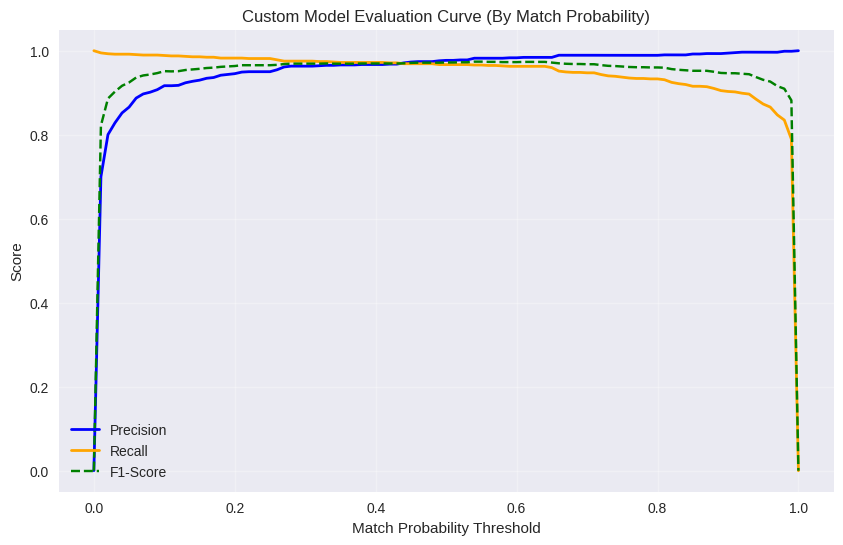

In [20]:
from notebook_helper import save_chart

plt.figure(figsize=(10, 6))
plt.plot(df_curve["threshold"], df_curve["precision"], label="Precision", color="blue", lw=2)
plt.plot(df_curve["threshold"], df_curve["recall"], label="Recall", color="orange", lw=2)
plt.plot(df_curve["threshold"], df_curve["f1_score"], label="F1-Score", color="green", linestyle="--")

plt.title("Custom Model Evaluation Curve (By Match Probability)")
plt.xlabel("Match Probability Threshold")
plt.ylabel("Score")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

# Save it using our helper:
save_chart(plt.gcf(), NOTEBOOK_NAME, "threshold_curve")
plt.show()
plt.close()

### Reviewing our results

In [21]:
linker.evaluation.accuracy_analysis_from_labels_column(
    GROUND_TRUTH_ID_COL, 
    output_type="threshold_selection",
    add_metrics=["f1", "accuracy"]
)

Blocking time: 1.42 seconds
Predict time: 1.69 seconds


alt.HConcatChart(...)

In [22]:
linker.evaluation.unlinkables_chart()

alt.LayerChart(...)

In [23]:
from notebook_helper import get_savable_visualisations, save_threshold_curve

viz = get_savable_visualisations(NOTEBOOK_NAME, linker)
viz.match_weights_chart().save_image("match_weights_chart")
viz.unlinkables_chart().save_image("unlinkables_chart")

/home/local/KLASS/steven.zhu/miniconda3/envs/GlobalEM/lib/python3.11/site-packages/altair/vegalite/v6/api.py:4138: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891
  return _tp.from_dict(dct, validate=validate)


'/home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/images/splink_local_demo/unlinkables_chart.png'

### Global Aggregation

We explore different aggregation functions. For each of them, we review the heatmap of the sore matrix,
the distribution of aggregated scores, and the curve.

In [24]:
from notebook_helper import (
    aggregate_entity_pair_matched_pairs,
    compute_source_sizes,
    calculate_match_density,
    calculate_weighted_jaccard,
    calculate_weighted_overlap,
    calculate_score_prob_ratio,
    second_layer_splink_evaluation,
    save_score_distribution_plot,
    save_precision_recall_curve,
    get_savable_visualisations
)

U_BASE = linker._settings_obj._probability_two_random_records_match

aggregated_df = aggregate_entity_pair_matched_pairs(
    pd_predict,
    id_columns=['local_source_id_l', 'local_source_id_r']
)

print("Aggregated entity-pair DataFrame shape:", aggregated_df.shape)
print("\nColumns:", list(aggregated_df.columns))
print("\nFirst 5 rows:")
display(aggregated_df.head())

/home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/helpers/entity_resolution_aggregation.py:247: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(apply_agg_functions)


Aggregated entity-pair DataFrame shape: (2500, 8)

Columns: ['local_source_id_l', 'local_source_id_r', 'sum_p', 'max_w', 'observed_edges', 'top_3_mean_w', 'score_noisy_or', 'score_softmax_p']

First 5 rows:


,local_source_id_l,local_source_id_r,sum_p,max_w,observed_edges,top_3_mean_w,score_noisy_or,score_softmax_p
0,DF1_100000,DF1_100002,0.000140,-13.140251,599,-15.670071,0.000140,2.336184e-07
1,DF1_100000,DF1_100004,0.007753,-7.018612,1013,-12.342268,0.007752,7.711672e-06
2,DF1_100000,DF1_100024,0.000079,-14.020201,780,-15.977130,0.000079,1.014311e-07
3,DF1_100000,DF1_100026,0.001226,-10.644153,1217,-11.707741,0.001226,1.008173e-06
4,DF1_100000,DF1_100027,0.000472,-11.087134,1707,-16.123067,0.000472,2.768090e-07


In [25]:
source_sizes = compute_source_sizes(df1, df2, 'local_source_id')

def add_structural_metrics(row):
    # Get sizes for left and right entities
    size_l = source_sizes.get(row['local_source_id_l'], {'size_l': 0})['size_l']
    size_r = source_sizes.get(row['local_source_id_r'], {'size_r': 0})['size_r']
    
    # Match density
    row['match_density'] = calculate_match_density(
        row['sum_p'], size_l, size_r
    )
    # Weighted Jaccard
    row['weighted_jaccard'] = calculate_weighted_jaccard(
        row['sum_p'], size_l, size_r
    )
    # Weighted overlap
    row['weighted_overlap'] = calculate_weighted_overlap(
        row['sum_p'], size_l, size_r
    )
    # Score-probability expected ratio (requires u_base from your Splink model)
    # You can estimate u_base as the average match probability from the prior
    # or use the m/u probabilities from the linker; here we use a placeholder.
    # Replace u_base_estimate with your actual value from the linker training.
    u_base_estimate = U_BASE  # <-- UPDATE THIS with your linker's u probability
    row['score_prob_expected_ratio'] = calculate_score_prob_ratio(
        row['sum_p'], size_l, size_r, u_base_estimate
    )
    return row

aggregated_with_metrics = aggregated_df.apply(add_structural_metrics, axis=1)

print("\nAfter adding structural metrics:")
display(aggregated_with_metrics[['local_source_id_l', 'local_source_id_r',
                               'sum_p', 'match_density', 'weighted_jaccard',
                               'weighted_overlap', 'score_noisy_or', 'score_softmax_p' ,'score_prob_expected_ratio']].head())



After adding structural metrics:


,local_source_id_l,local_source_id_r,sum_p,match_density,weighted_jaccard,weighted_overlap,score_noisy_or,score_softmax_p,score_prob_expected_ratio
0,DF1_100000,DF1_100002,0.000140,8.328857e-08,1.627035e-06,0.000005,0.000140,2.336184e-07,-6.715034
1,DF1_100000,DF1_100004,0.007753,2.825504e-06,7.384529e-05,0.000158,0.007752,7.711672e-06,-3.197892
2,DF1_100000,DF1_100024,0.000079,3.531807e-08,8.240890e-07,0.000002,0.000079,1.014311e-07,-7.567509
3,DF1_100000,DF1_100026,0.001226,3.711589e-07,1.066367e-05,0.000022,0.001226,1.008173e-06,-5.227017
4,DF1_100000,DF1_100027,0.000472,1.016140e-07,3.397867e-06,0.000008,0.000472,2.768090e-07,-6.521165


In [26]:

# Get unique entity IDs
left_entities = sorted(aggregated_df['local_source_id_l'].unique())
right_entities = sorted(aggregated_df['local_source_id_r'].unique())

# Create an empty matrix
similarity_matrix = np.zeros((len(left_entities), len(right_entities)))

# Fill with sum_p values
for _, row in aggregated_df.iterrows():
    i = left_entities.index(row['local_source_id_l'])
    j = right_entities.index(row['local_source_id_r'])
    similarity_matrix[i, j] = row['sum_p']

# Save heatmap
from notebook_helper import save_aggregation_heatmap
save_aggregation_heatmap(
    NOTEBOOK_NAME,
    similarity_matrix,
    row_labels=left_entities,
    col_labels=right_entities,
    title="Heatmap of Sum Probabilities (Σ p)\nEntity A vs Entity B",
    xlabel="Dataset B Entities",
    ylabel="Dataset A Entities",
    cmap="viridis",
    chart_name="heatmap_sum_p"
)
print("\nHeatmap saved successfully.")



Heatmap saved successfully.


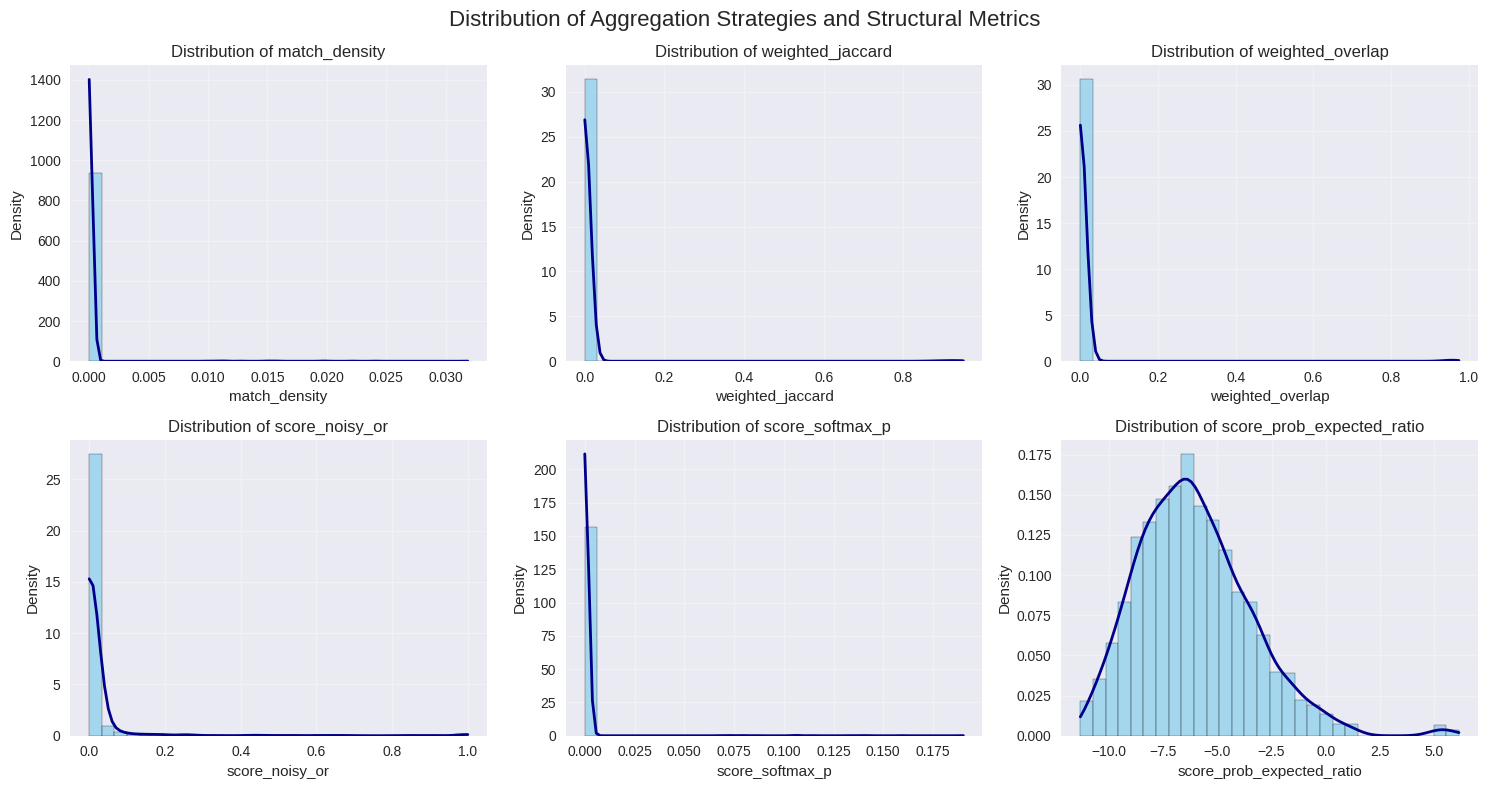

In [27]:
metrics_to_plot = [
    'match_density',
    'weighted_jaccard', 
    'weighted_overlap',
    'score_noisy_or',
    'score_softmax_p',
    'score_prob_expected_ratio'
]

# Create subplot layout
n_metrics = len(metrics_to_plot)
n_cols = min(3, n_metrics)
n_rows = (n_metrics + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
if n_metrics == 1:
    axes = [axes]
elif n_rows == 1:
    axes = axes.reshape(1, -1)

axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]

# Plot each metric
for idx, col in enumerate(metrics_to_plot):
    if idx >= len(axes_flat):
        break
    ax = axes_flat[idx]
    
    # Get data and remove NaNs
    data = aggregated_with_metrics[col].dropna()
    if len(data) == 0:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{col} (No Data)')
        continue
    
    # Create histogram with KDE
    ax.hist(data, bins=30, alpha=0.7, color='skyblue', edgecolor='black', density=True)
    
    # Add KDE if scipy is available
    try:
        from scipy import stats
        kde = stats.gaussian_kde(data)
        x_range = np.linspace(data.min(), data.max(), 100)
        ax.plot(x_range, kde(x_range), 'darkblue', linewidth=2)
    except ImportError:
        pass  # Skip KDE if scipy not available
    
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(metrics_to_plot), len(axes_flat)):
    axes_flat[idx].set_visible(False)

plt.suptitle('Distribution of Aggregation Strategies and Structural Metrics', fontsize=16)
plt.tight_layout()

# In notebook: show_and_save_fig(fig, "splink_local_demo", "combined_aggregation_metrics_distribution")
plt.show()  # For script execution

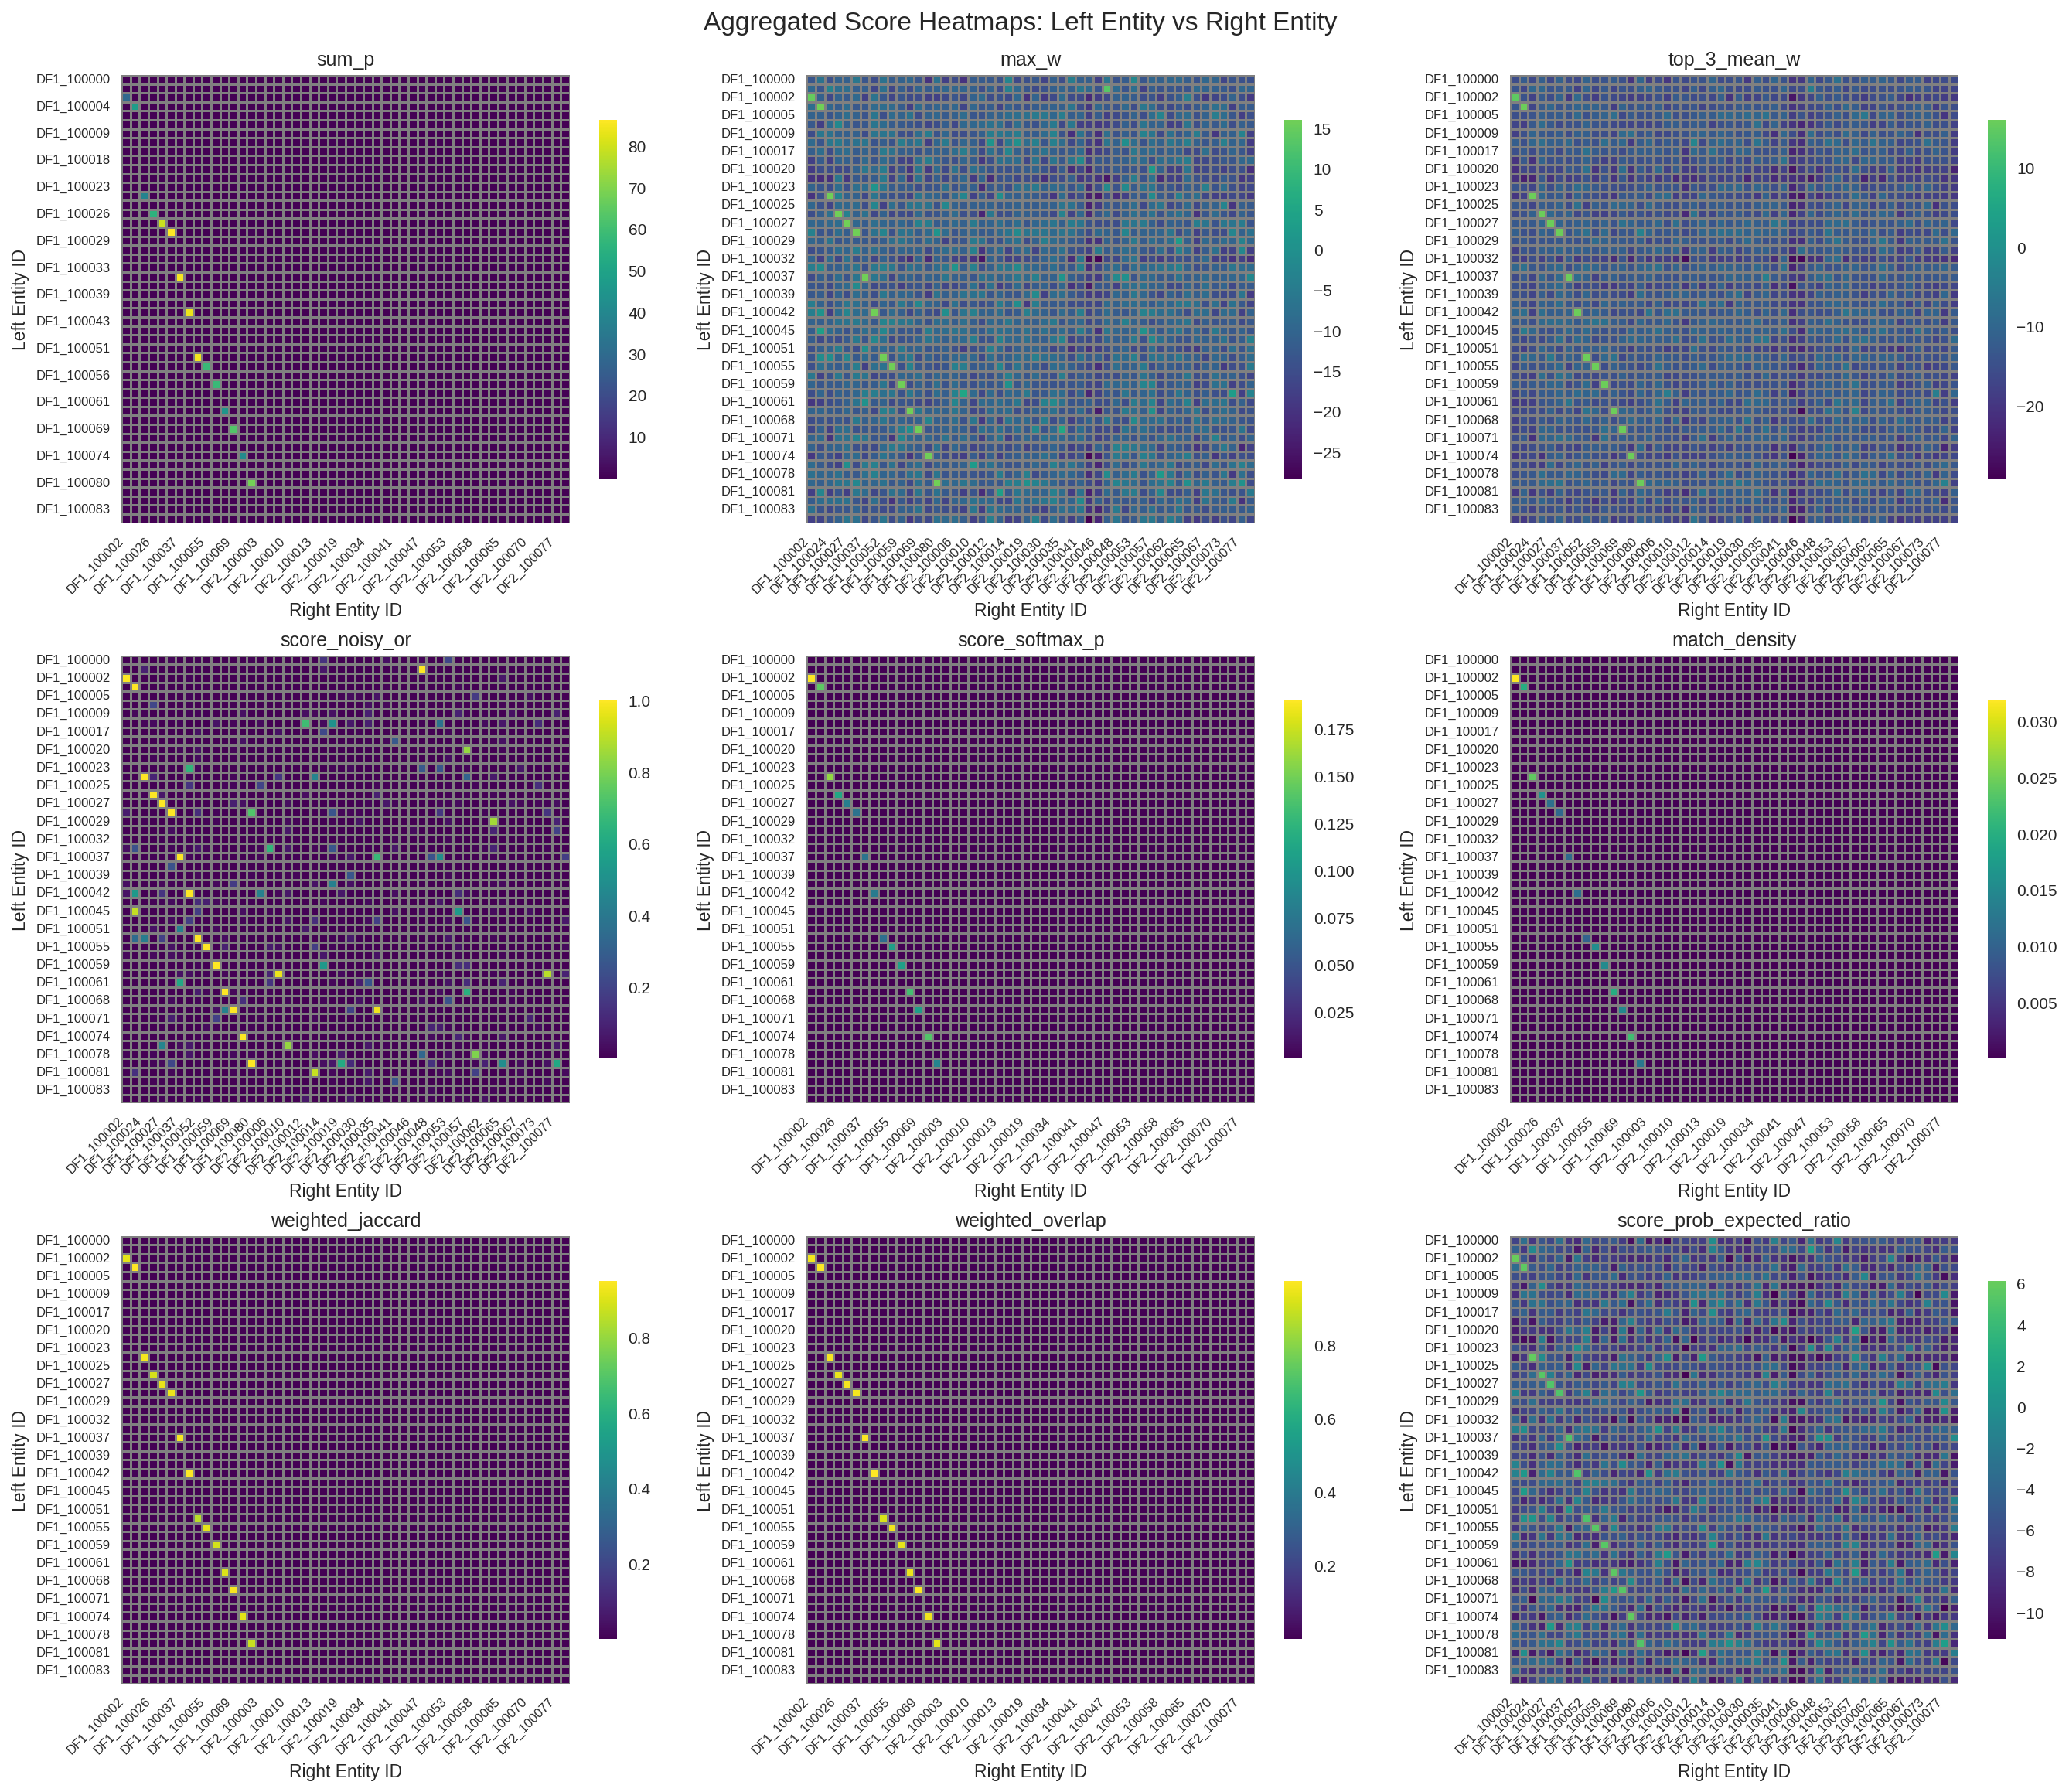

Figure saved to: /home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/images/splink_local_demo/aggregation_score_heatmaps.png


In [28]:
from helpers.visualization_helper import plot_aggregation_heatmaps, plot_threshold_evaluation

# Generate combined heatmap and precision-recall curves
plot_aggregation_heatmaps(
    aggregated_df=aggregated_with_metrics,  # or your aggregated dataframe
    score_columns=[
        'sum_p', 'max_w', 'top_3_mean_w', 
        'score_noisy_or', 'score_softmax_p',
        'match_density', 'weighted_jaccard', 
        'weighted_overlap', 'score_prob_expected_ratio'
    ],
    notebook_dir=NOTEBOOK_NAME
)

Computing entity-level ground truth for threshold evaluation...
Found 15 true entity pairs out of 2500 total pairs (0.60%)


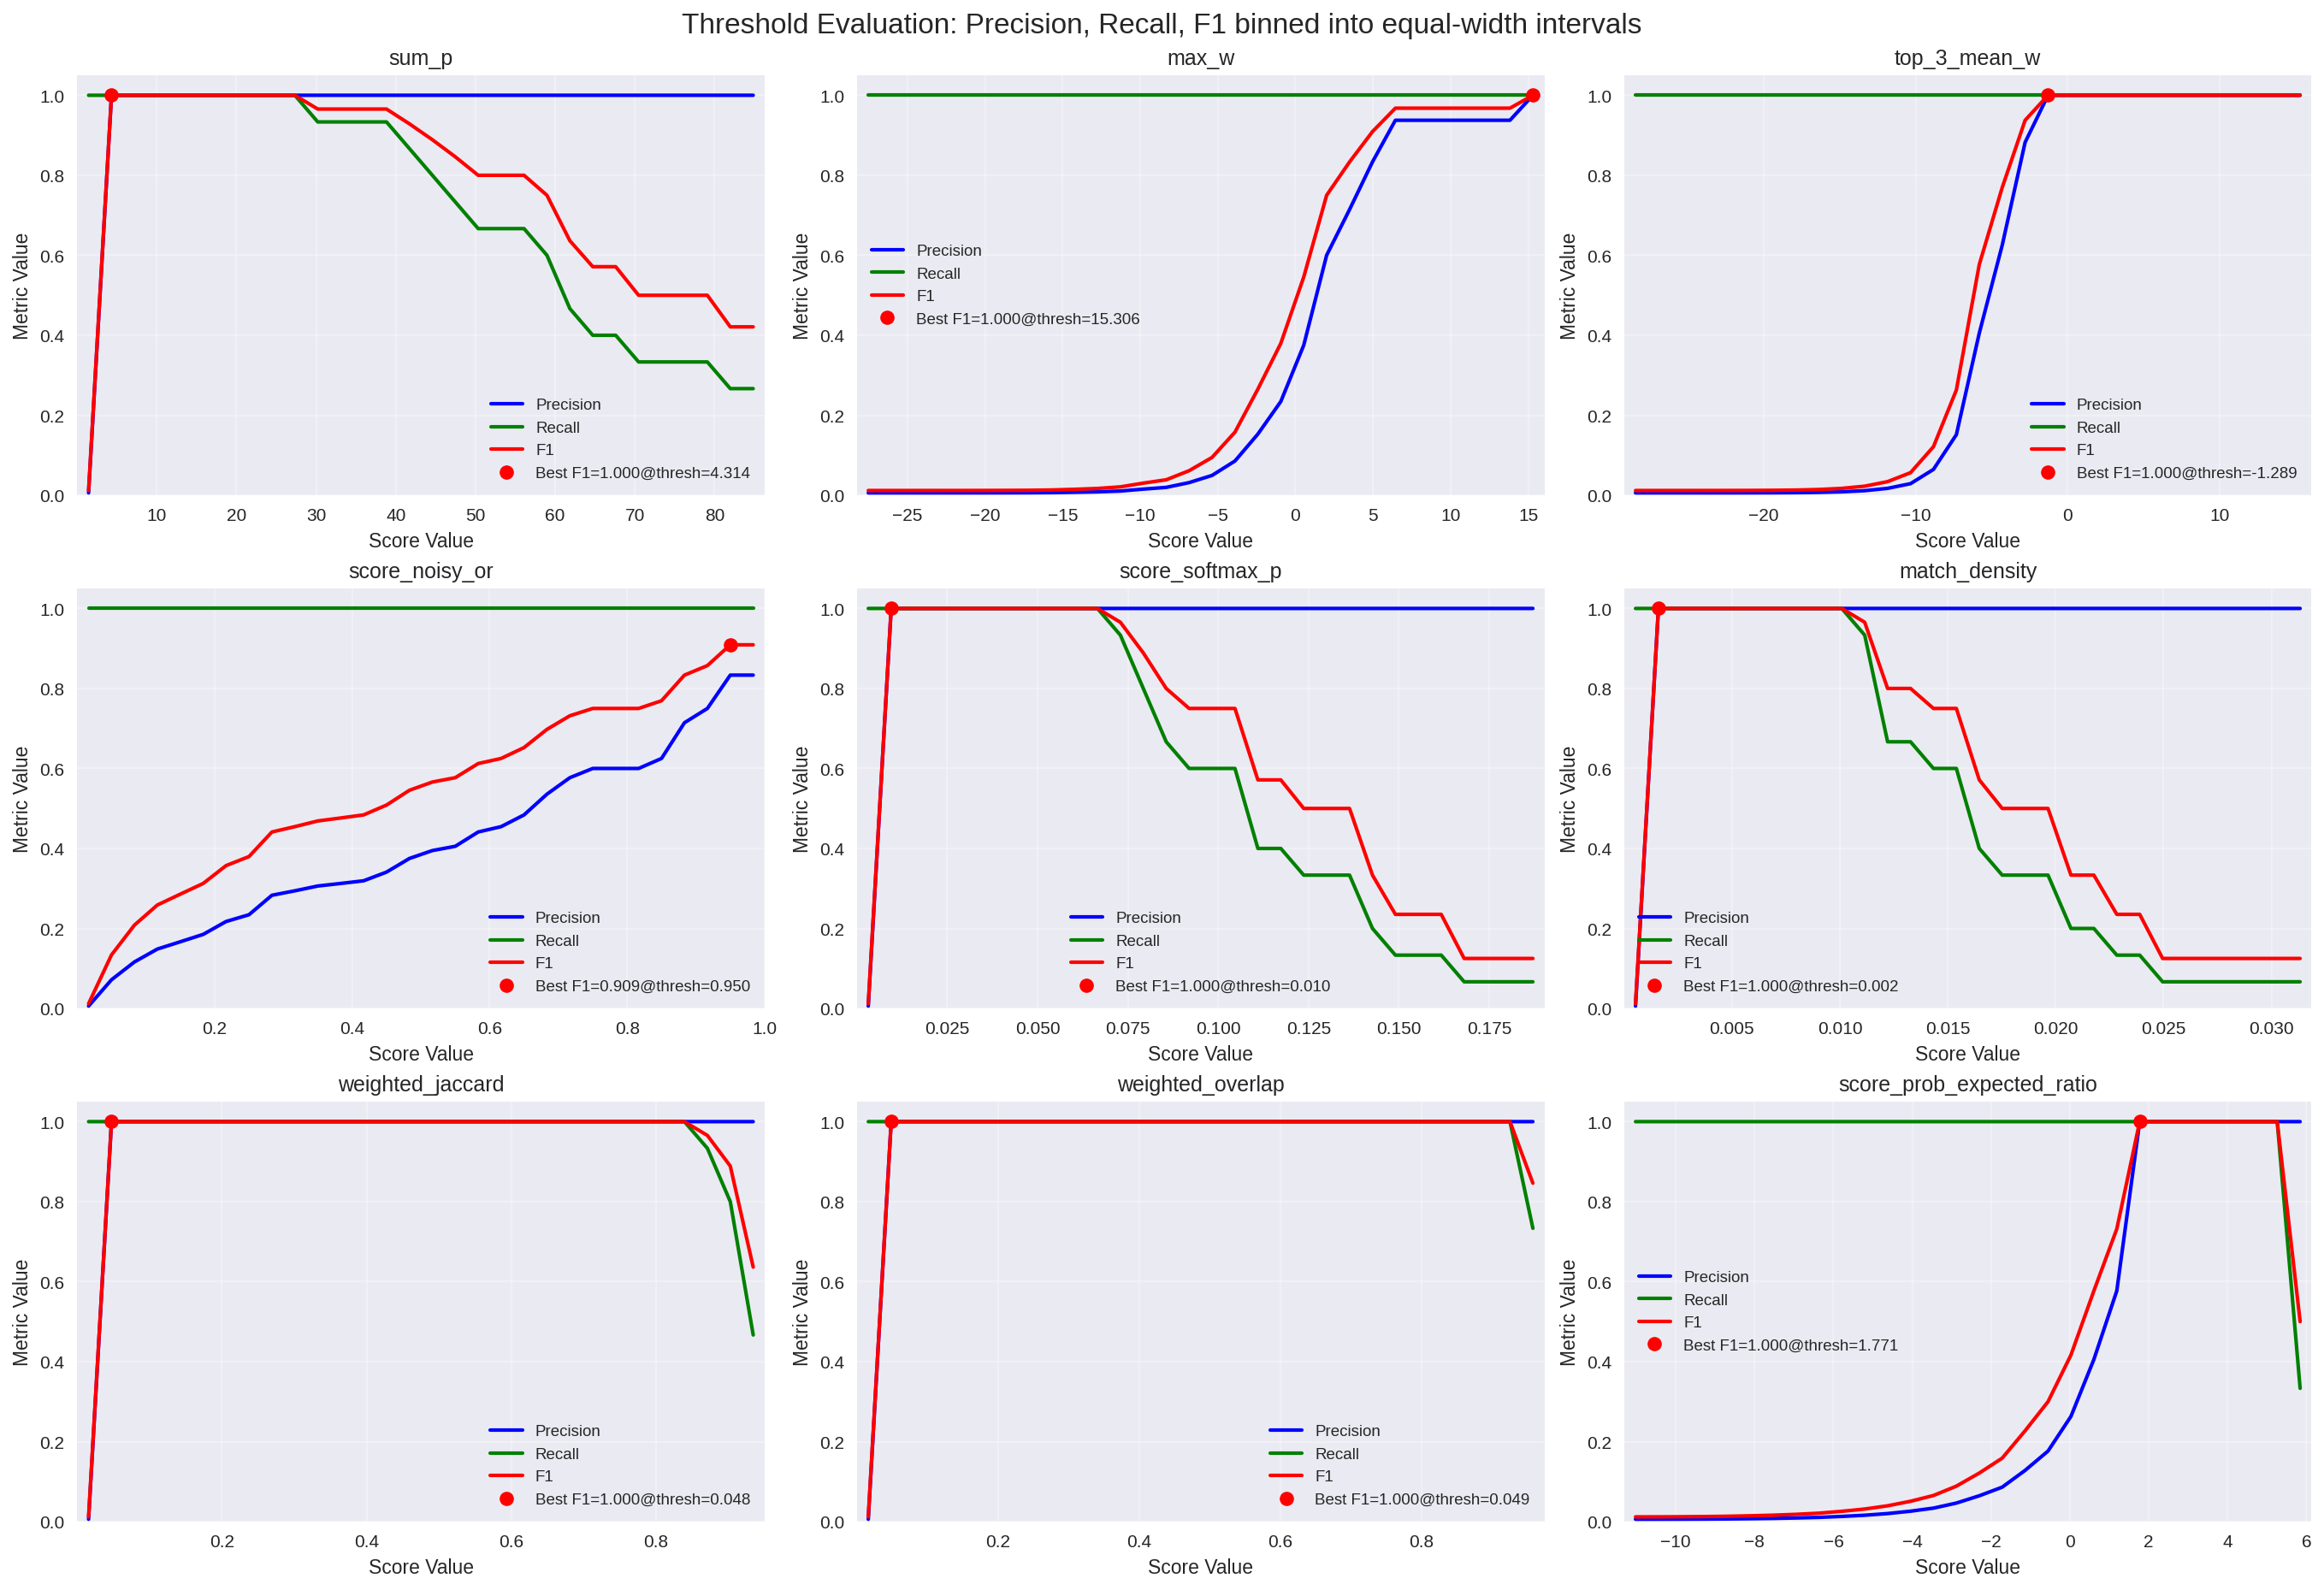

Figure saved to: /home/local/KLASS/steven.zhu/Documents/entity_resolution_demo/notebooks/images/splink_local_demo/threshold_evaluation_binned.png


In [29]:
plot_threshold_evaluation(
    aggregated_df=aggregated_with_metrics,
    df1=df1,
    df2=df2,
    score_columns=[
        'sum_p', 'max_w', 'top_3_mean_w', 
        'score_noisy_or', 'score_softmax_p',
        'match_density', 'weighted_jaccard', 
        'weighted_overlap', 'score_prob_expected_ratio'
    ],
    notebook_dir=NOTEBOOK_NAME,
    bins=30  # 30 bins as requested
)